In [53]:
import kagglehub
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

# Download the latest version of the dataset from KaggleHub
path = kagglehub.dataset_download("sehaj1104/student-placement-prediction-dataset-2026")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'student-placement-prediction-dataset-2026' dataset.
Path to dataset files: /kaggle/input/student-placement-prediction-dataset-2026


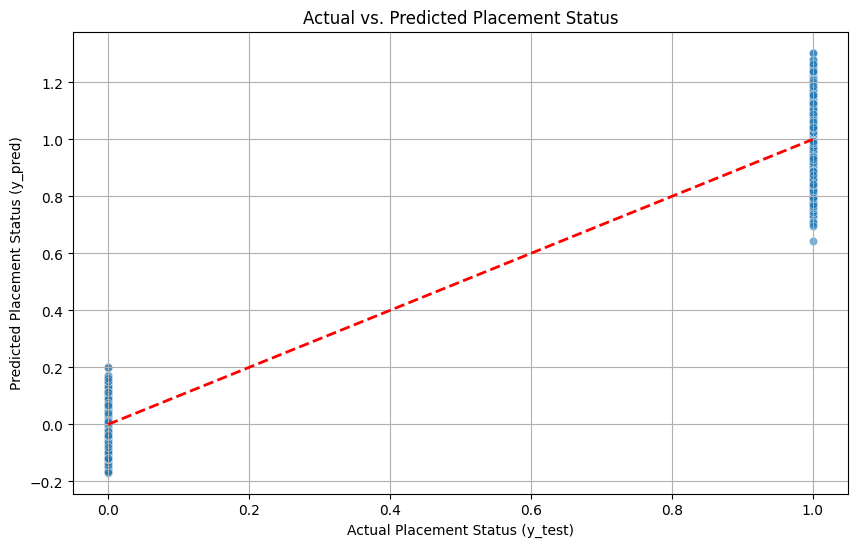

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot of actual vs. predicted values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.xlabel('Actual Placement Status (y_test)')
plt.ylabel('Predicted Placement Status (y_pred)')
plt.title('Actual vs. Predicted Placement Status')

# Plot a diagonal line representing perfect predictions
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.grid(True)
plt.show()

In [54]:
# Read the CSV file into a pandas DataFrame
df=pd.read_csv(f"{path}/student_placement_prediction_dataset_2026.csv")

In [55]:
# Display the entire DataFrame to inspect its contents
df

,student_id,age,gender,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,...,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,sleep_hours,study_hours_per_day,placement_status,salary_package_lpa
0,1,24,Male,7.53,IT,Tier 2,4,6,1,99.238568,...,72.647009,77.463863,2,63.382726,52.938240,Yes,6.7,3.6,Not Placed,0.00
1,2,21,Male,7.92,CSE,Tier 2,1,3,6,80.966123,...,61.699110,88.887600,1,73.694605,60.198856,No,4.4,2.3,Not Placed,0.00
2,3,22,Female,8.60,EEE,Tier 1,0,1,1,49.177184,...,87.396911,74.153265,0,63.329294,43.708803,No,8.8,5.9,Placed,11.99
3,4,24,Male,6.68,CSE,Tier 1,0,2,2,79.359084,...,58.401069,87.635955,1,47.636099,56.549154,Yes,8.1,4.4,Not Placed,0.00
4,5,20,Female,8.43,IT,Tier 3,1,4,3,65.018573,...,74.489201,79.120749,1,0.000000,67.268893,No,8.7,3.4,Placed,12.16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99996,21,Male,7.97,Mechanical,Tier 2,0,3,5,71.483407,...,57.738311,75.471631,0,54.399022,66.446410,Yes,8.0,4.3,Placed,14.54
99996,99997,18,Female,7.79,CSE,Tier 1,1,1,2,78.960574,...,80.076688,77.286948,1,33.692154,69.025632,Yes,4.4,3.1,Not Placed,0.00
99997,99998,20,Female,6.71,IT,Tier 2,2,4,4,66.691775,...,70.797752,93.115933,0,64.989215,32.733645,Yes,7.6,2.9,Placed,13.45
99998,99999,19,Female,7.21,CSE,Tier 2,2,3,0,67.214893,...,68.182555,71.306355,1,72.478779,32.205517,No,4.9,2.8,Not Placed,0.00


In [56]:
# Check for missing values in each column and sum them up
df.isnull().sum()

,0
student_id,0
age,0
gender,0
cgpa,0
branch,0
college_tier,0
internships_count,0
projects_count,0
certifications_count,0
coding_skill_score,0


In [57]:
# Initialize LabelEncoder for categorical feature encoding
le=LabelEncoder()
# Apply Label Encoding to convert categorical columns into numerical representation
df['gender']=le.fit_transform(df['gender'])
df['branch']=le.fit_transform(df['branch'])
df['college_tier']=le.fit_transform(df['college_tier'])
df['volunteer_experience']=le.fit_transform(df['volunteer_experience'])
df['placement_status']=le.fit_transform(df['placement_status'])

In [58]:
# Display the DataFrame after applying Label Encoding to see the changes
df

,student_id,age,gender,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,...,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,sleep_hours,study_hours_per_day,placement_status,salary_package_lpa
0,1,24,1,7.53,4,1,4,6,1,99.238568,...,72.647009,77.463863,2,63.382726,52.938240,1,6.7,3.6,0,0.00
1,2,21,1,7.92,0,1,1,3,6,80.966123,...,61.699110,88.887600,1,73.694605,60.198856,0,4.4,2.3,0,0.00
2,3,22,0,8.60,3,0,0,1,1,49.177184,...,87.396911,74.153265,0,63.329294,43.708803,0,8.8,5.9,1,11.99
3,4,24,1,6.68,0,0,0,2,2,79.359084,...,58.401069,87.635955,1,47.636099,56.549154,1,8.1,4.4,0,0.00
4,5,20,0,8.43,4,2,1,4,3,65.018573,...,74.489201,79.120749,1,0.000000,67.268893,0,8.7,3.4,1,12.16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99996,21,1,7.97,5,1,0,3,5,71.483407,...,57.738311,75.471631,0,54.399022,66.446410,1,8.0,4.3,1,14.54
99996,99997,18,0,7.79,0,0,1,1,2,78.960574,...,80.076688,77.286948,1,33.692154,69.025632,1,4.4,3.1,0,0.00
99997,99998,20,0,6.71,4,1,2,4,4,66.691775,...,70.797752,93.115933,0,64.989215,32.733645,1,7.6,2.9,1,13.45
99998,99999,19,0,7.21,0,1,2,3,0,67.214893,...,68.182555,71.306355,1,72.478779,32.205517,0,4.9,2.8,0,0.00


In [59]:
# Separate features (X) and target variable (y)
X=df.drop(columns=['placement_status'])
y=df['placement_status']

In [60]:
# Split the data into training and testing sets (80% train, 20% test)
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=16)

In [61]:
# Initialize the Linear Regression model
from sklearn.linear_model import LinearRegression
model=LinearRegression()

In [62]:
# Train the Linear Regression model using the training data
model.fit(x_train,y_train)

LinearRegression()

In [63]:
# Make predictions on the test set
y_pred=model.predict(x_test)

In [64]:
# Calculate and print the Mean Squared Error (MSE) of the model's predictions
print(mean_squared_error(y_test,y_pred))

0.0051362022855703385


In [65]:
# Calculate and print the R-squared (R2) score of the model's predictions
print(r2_score(y_test,y_pred))

0.9793091965485653
